# Лабораторная работа №4
## Улучшение качества модели

**Дисциплина:** Анализ данных и искусственный интеллект

**Датасет:** [Student Mental Health & Burnout (1M)](https://www.kaggle.com/datasets/ayeshasiddiqa123/student-health) — Kaggle

### Цель работы
Научиться повышать качество моделей и сравнивать алгоритмы.

### План работы
1. Загрузка данных и воспроизведение базовой модели из ЛР №3 (Linear Regression).
2. Подбор гиперпараметров для линейных моделей (Ridge, Lasso) через `GridSearchCV`.
3. Обучение альтернативной модели — **Decision Tree** и **Random Forest**.
4. Подбор гиперпараметров для деревьев через `GridSearchCV`.
5. Анализ переобучения (train vs test, learning curves).
6. Сравнительная таблица моделей.
7. Выводы о лучшей модели.

## 1. Импорты и настройки

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold,
    cross_val_score, learning_curve
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline

## 2. Загрузка данных и подготовка

Используем пайплайн из ЛР №2–3. Чтобы GridSearch и RandomForest работали в разумное время на 1 млн записей, **берём стратифицированную подвыборку 100 000 строк** — этого достаточно для устойчивых оценок и сравнения моделей.

In [2]:
def clip_outliers_iqr(data: pd.DataFrame, columns: list[str], k: float = 1.5) -> pd.DataFrame:
    data = data.copy()
    q1, q3 = data[columns].quantile(0.25), data[columns].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    data[columns] = data[columns].clip(lower=lower, upper=upper, axis=1)
    return data


def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates().reset_index(drop=True)
    exclude = {'age', 'academic_year'}
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]
    return clip_outliers_iqr(df, num_cols)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['psych_load_index'] = (df['stress_level'] + df['anxiety_score'] + df['depression_score']) / 3
    df['sleep_study_balance'] = df['sleep_hours'] / (df['study_hours_per_day'] + 1)
    df['digital_load'] = df['screen_time'] + df['internet_usage']
    df['external_pressure'] = (df['exam_pressure'] + df['financial_stress'] + df['family_expectation']) / 3
    df['support_to_stress'] = df['social_support'] / (df['stress_level'] + 1)
    df['is_sleep_deprived'] = (df['sleep_hours'] < 6).astype(int)
    df['age_group'] = pd.cut(
        df['age'], bins=[16, 19, 22, 25, 30],
        labels=['17-19', '20-22', '23-25', '26-29']
    ).astype(str)
    return df


def prepare_dataset(path: str, target: str = 'burnout_score',
                    sample_size: int | None = None) -> tuple[pd.DataFrame, pd.Series]:
    df = pd.read_csv(path)
    if sample_size is not None and sample_size < len(df):
        df = df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True)
    df = basic_clean(df)
    df = add_features(df)
    leaky = ['mental_health_index', 'dropout_risk', 'risk_level']
    y = df[target].copy()
    X = df.drop(columns=[target] + leaky)
    return X, y

In [3]:
TARGET = 'burnout_score'
SAMPLE_SIZE = 100_000  # для скорости GridSearch и RandomForest

X, y = prepare_dataset('../student_mental_health_burnout_1M.csv',
                        target=TARGET, sample_size=SAMPLE_SIZE)

print(f'Выборка: {X.shape[0]:,} строк, {X.shape[1]} признаков')
print(f'Среднее таргета: {y.mean():.3f},  std: {y.std():.3f}')

Выборка: 100,000 строк, 23 признаков
Среднее таргета: 1.787,  std: 1.655


In [4]:
# Train/test split — точно так же, как в ЛР №3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')

# Препроцессор — тоже из ЛР №3
nominal_cols = ['gender']
ordinal_map = {'age_group': ['17-19', '20-22', '23-25', '26-29']}
numeric_cols = [c for c in X_train.columns if c not in nominal_cols + list(ordinal_map)]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('ord', OrdinalEncoder(categories=[ordinal_map['age_group']],
                                handle_unknown='use_encoded_value', unknown_value=-1), ['age_group']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

Train: (80000, 23),  Test: (20000, 23)


## 3. Утилиты для оценки моделей

Чтобы избежать дублирования кода, выделим общие функции: обучение, расчёт метрик и сохранение результатов в общую таблицу.

In [5]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """MAE, RMSE, R² для регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred),
    }


def evaluate_model(name: str, model, X_tr, y_tr, X_te, y_te) -> dict:
    """Обучает модель, рассчитывает метрики train/test, измеряет время."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    m_tr = regression_metrics(y_tr, pred_tr)
    m_te = regression_metrics(y_te, pred_te)
    return {
        'model': name,
        'fit_time_s': round(fit_time, 2),
        'MAE_train': round(m_tr['MAE'], 4),
        'MAE_test':  round(m_te['MAE'], 4),
        'RMSE_train': round(m_tr['RMSE'], 4),
        'RMSE_test':  round(m_te['RMSE'], 4),
        'R2_train': round(m_tr['R2'], 4),
        'R2_test':  round(m_te['R2'], 4),
        'overfit_gap': round(m_tr['R2'] - m_te['R2'], 4),
        'estimator': model,
    }


results: list[dict] = []

## 4. Базовая модель (Linear Regression) — воспроизведение ЛР №3

Обучим эталон без настройки гиперпараметров, чтобы сравнивать с ним последующие улучшения.

In [6]:
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression()),
])

res_lr = evaluate_model('1. LinearRegression (baseline)', lr_pipeline,
                         X_train, y_train, X_test, y_test)
results.append(res_lr)
print(f"MAE_test = {res_lr['MAE_test']},  R²_test = {res_lr['R2_test']},  fit = {res_lr['fit_time_s']} s")

MAE_test = 0.683,  R²_test = 0.7285,  fit = 0.08 s


## 5. Подбор гиперпараметров для линейных моделей

Сравним базовый `LinearRegression` с регуляризованными версиями:

- **Ridge** (L2-регуляризация) — сжимает коэффициенты к нулю, помогает при мультиколлинеарности.
- **Lasso** (L1-регуляризация) — обнуляет малые коэффициенты, выполняет отбор признаков.

Подбираем гиперпараметр `alpha` (сила регуляризации) через **`GridSearchCV`** с 5-fold кросс-валидацией по метрике R².

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Ridge ---
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=cv, scoring='r2', n_jobs=-1, return_train_score=True,
)
ridge_grid.fit(X_train, y_train)
print(f'Ridge best alpha:    {ridge_grid.best_params_["model__alpha"]}')
print(f'Ridge best CV R²:    {ridge_grid.best_score_:.4f}')

# --- Lasso ---
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(random_state=RANDOM_STATE, max_iter=5000))])
lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]},
    cv=cv, scoring='r2', n_jobs=-1, return_train_score=True,
)
lasso_grid.fit(X_train, y_train)
print(f'\nLasso best alpha:    {lasso_grid.best_params_["model__alpha"]}')
print(f'Lasso best CV R²:    {lasso_grid.best_score_:.4f}')

Ridge best alpha:    10.0
Ridge best CV R²:    0.7267

Lasso best alpha:    0.001
Lasso best CV R²:    0.7268


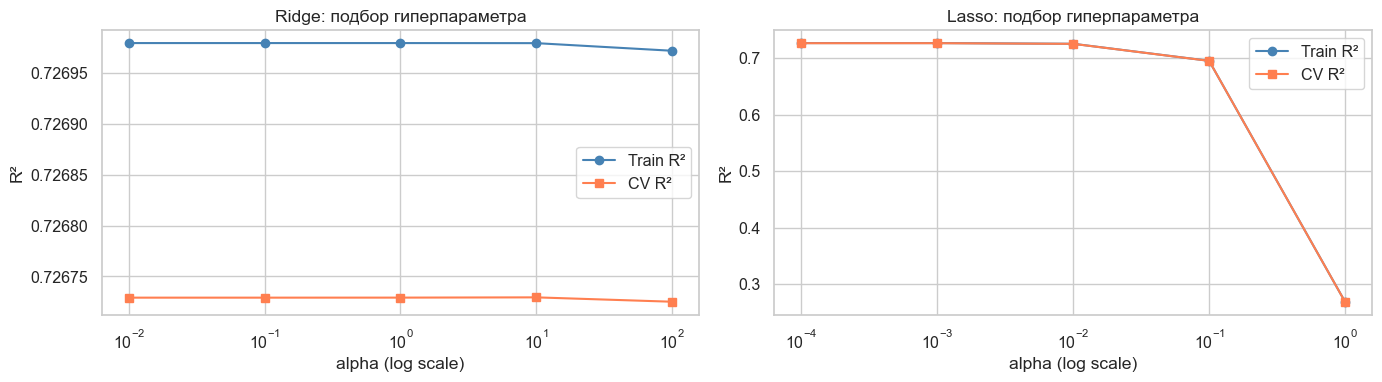

In [8]:
# Записываем результаты подобранных моделей в общую таблицу
results.append(evaluate_model('2. Ridge (GridSearch)', ridge_grid.best_estimator_,
                               X_train, y_train, X_test, y_test))
results.append(evaluate_model('3. Lasso (GridSearch)', lasso_grid.best_estimator_,
                               X_train, y_train, X_test, y_test))

# Визуализация: R² от alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, grid, title in [(axes[0], ridge_grid, 'Ridge'),
                         (axes[1], lasso_grid, 'Lasso')]:
    cvr = pd.DataFrame(grid.cv_results_)
    ax.plot(cvr['param_model__alpha'], cvr['mean_train_score'], 'o-', label='Train R²', color='steelblue')
    ax.plot(cvr['param_model__alpha'], cvr['mean_test_score'],  's-', label='CV R²',   color='coral')
    ax.set_xscale('log')
    ax.set_xlabel('alpha (log scale)')
    ax.set_ylabel('R²')
    ax.set_title(f'{title}: подбор гиперпараметра')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Альтернативная модель — Decision Tree

Дерево решений принципиально отличается от линейной регрессии: оно может моделировать **нелинейные зависимости** и **взаимодействия** между признаками без явного feature engineering.

Подбираем глубину (`max_depth`) и минимальное число объектов в листе (`min_samples_leaf`).

In [9]:
tree_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

tree_grid = GridSearchCV(
    tree_pipe,
    param_grid={
        'model__max_depth':         [5, 8, 12, 15, None],
        'model__min_samples_leaf':  [10, 50, 200],
    },
    cv=cv, scoring='r2', n_jobs=-1, return_train_score=True,
)

t0 = time.perf_counter()
tree_grid.fit(X_train, y_train)
print(f'Время GridSearch для DecisionTree: {time.perf_counter() - t0:.1f} s')
print(f'Лучшие параметры:  {tree_grid.best_params_}')
print(f'Лучший CV R²:      {tree_grid.best_score_:.4f}')

# Также добавим «переобученное» дерево без ограничений — для иллюстрации overfitting
tree_overfit_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

results.append(evaluate_model('4. DecisionTree (без настройки)', tree_overfit_pipe,
                               X_train, y_train, X_test, y_test))
results.append(evaluate_model('5. DecisionTree (GridSearch)', tree_grid.best_estimator_,
                               X_train, y_train, X_test, y_test))

Время GridSearch для DecisionTree: 9.9 s
Лучшие параметры:  {'model__max_depth': 12, 'model__min_samples_leaf': 200}
Лучший CV R²:      0.7101


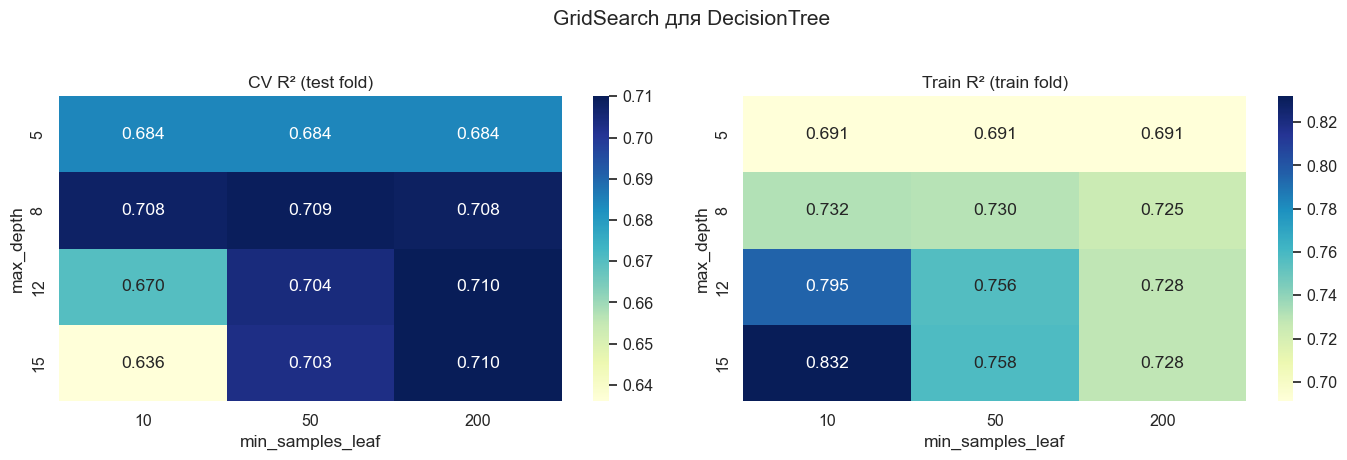

In [10]:
# Тепловая карта: R² по сетке (max_depth × min_samples_leaf)
tree_cvr = pd.DataFrame(tree_grid.cv_results_)
pivot_test = tree_cvr.pivot_table(
    index='param_model__max_depth',
    columns='param_model__min_samples_leaf',
    values='mean_test_score',
)
pivot_train = tree_cvr.pivot_table(
    index='param_model__max_depth',
    columns='param_model__min_samples_leaf',
    values='mean_train_score',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(pivot_test, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('CV R² (test fold)')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(pivot_train, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Train R² (train fold)')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')

plt.suptitle('GridSearch для DecisionTree', y=1.02)
plt.tight_layout()
plt.show()

## 7. Альтернативная модель — Random Forest

Случайный лес — ансамбль деревьев с **бэггингом** и случайным выбором признаков. Обычно даёт лучшее качество, чем одиночное дерево, и меньше склонен к переобучению.

In [11]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={
        'model__n_estimators':      [100, 200],
        'model__max_depth':         [10, 15, None],
        'model__min_samples_leaf':  [10, 50],
    },
    cv=3,  # 3-fold вместо 5 — RF медленный
    scoring='r2', n_jobs=-1, return_train_score=True,
)

t0 = time.perf_counter()
rf_grid.fit(X_train, y_train)
print(f'Время GridSearch для RandomForest: {time.perf_counter() - t0:.1f} s')
print(f'Лучшие параметры:  {rf_grid.best_params_}')
print(f'Лучший CV R²:      {rf_grid.best_score_:.4f}')

results.append(evaluate_model('6. RandomForest (GridSearch)', rf_grid.best_estimator_,
                               X_train, y_train, X_test, y_test))

Время GridSearch для RandomForest: 299.6 s
Лучшие параметры:  {'model__max_depth': 15, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Лучший CV R²:      0.7327


## 8. Анализ переобучения

### 8.1 Сравнение train vs test метрик

Большой разрыв `R²_train − R²_test` (gap) — индикатор переобучения. Хорошая модель: маленький gap и высокий R²_test.

In [12]:
results_df = pd.DataFrame(results).drop(columns='estimator')
results_df = results_df.sort_values('R2_test', ascending=False).reset_index(drop=True)

print('Сравнительная таблица моделей:')
results_df

Сравнительная таблица моделей:


,model,fit_time_s,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,overfit_gap
0,6. RandomForest (GridSearch),21.21,0.4970,0.6482,0.6604,0.8525,0.8405,0.7366,0.1039
1,3. Lasso (GridSearch),7.82,0.6785,0.6830,0.8641,0.8654,0.7269,0.7286,-0.0017
2,2. Ridge (GridSearch),0.06,0.6784,0.6830,0.8641,0.8655,0.7270,0.7285,-0.0016
3,1. LinearRegression (baseline),0.08,0.6784,0.6830,0.8641,0.8655,0.7270,0.7285,-0.0016
4,5. DecisionTree (GridSearch),1.08,0.6500,0.6743,0.8590,0.8890,0.7302,0.7136,0.0166
5,4. DecisionTree (без настройки),1.99,0.0000,0.9044,0.0000,1.2315,1.0000,0.4504,0.5496


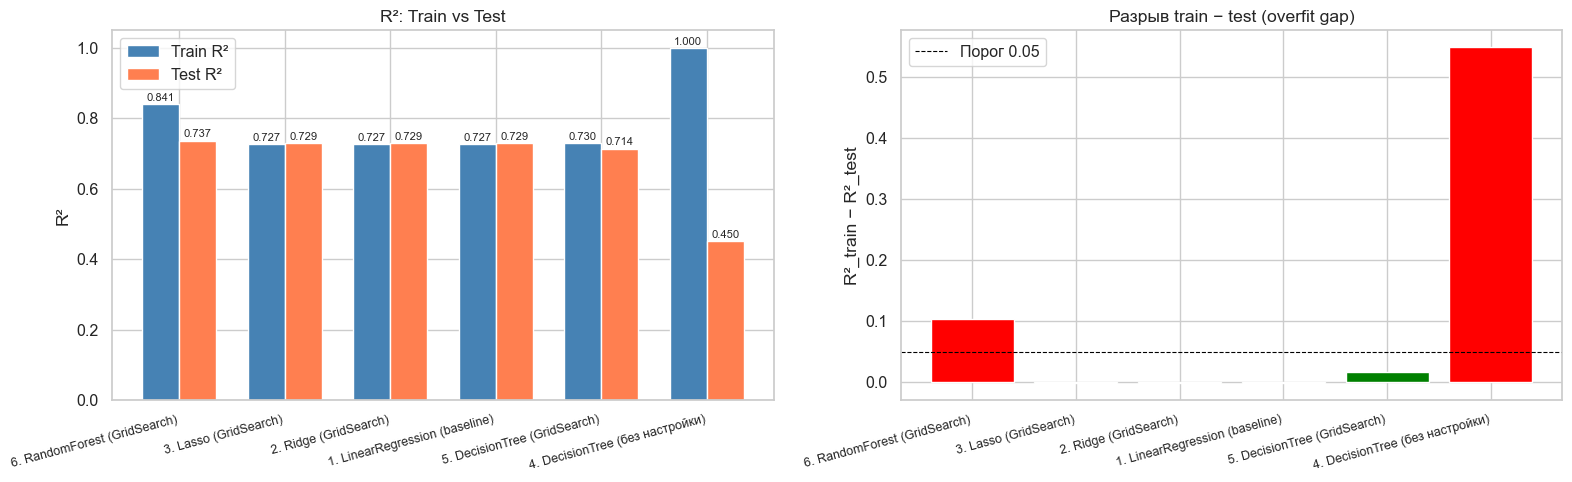

In [13]:
# Визуализация: train vs test R² для всех моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_order = results_df['model'].tolist()
x = np.arange(len(models_order))
width = 0.35

axes[0].bar(x - width/2, results_df['R2_train'], width, label='Train R²', color='steelblue')
axes[0].bar(x + width/2, results_df['R2_test'],  width, label='Test R²',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_order, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_title('R²: Train vs Test')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
for xi, (tr, te) in enumerate(zip(results_df['R2_train'], results_df['R2_test'])):
    axes[0].text(xi - width/2, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=8)
    axes[0].text(xi + width/2, te + 0.01, f'{te:.3f}', ha='center', fontsize=8)

# Gap = разница train − test
colors_gap = ['red' if g > 0.05 else 'green' for g in results_df['overfit_gap']]
axes[1].bar(x, results_df['overfit_gap'], color=colors_gap)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_order, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('R²_train − R²_test')
axes[1].set_title('Разрыв train − test (overfit gap)')
axes[1].axhline(0.05, color='black', linestyle='--', lw=0.8, label='Порог 0.05')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.2 Learning Curves — устойчивость качества при росте обучающей выборки

Сравним кривые обучения для трёх ключевых моделей: Linear Regression, DecisionTree без настройки и RandomForest.

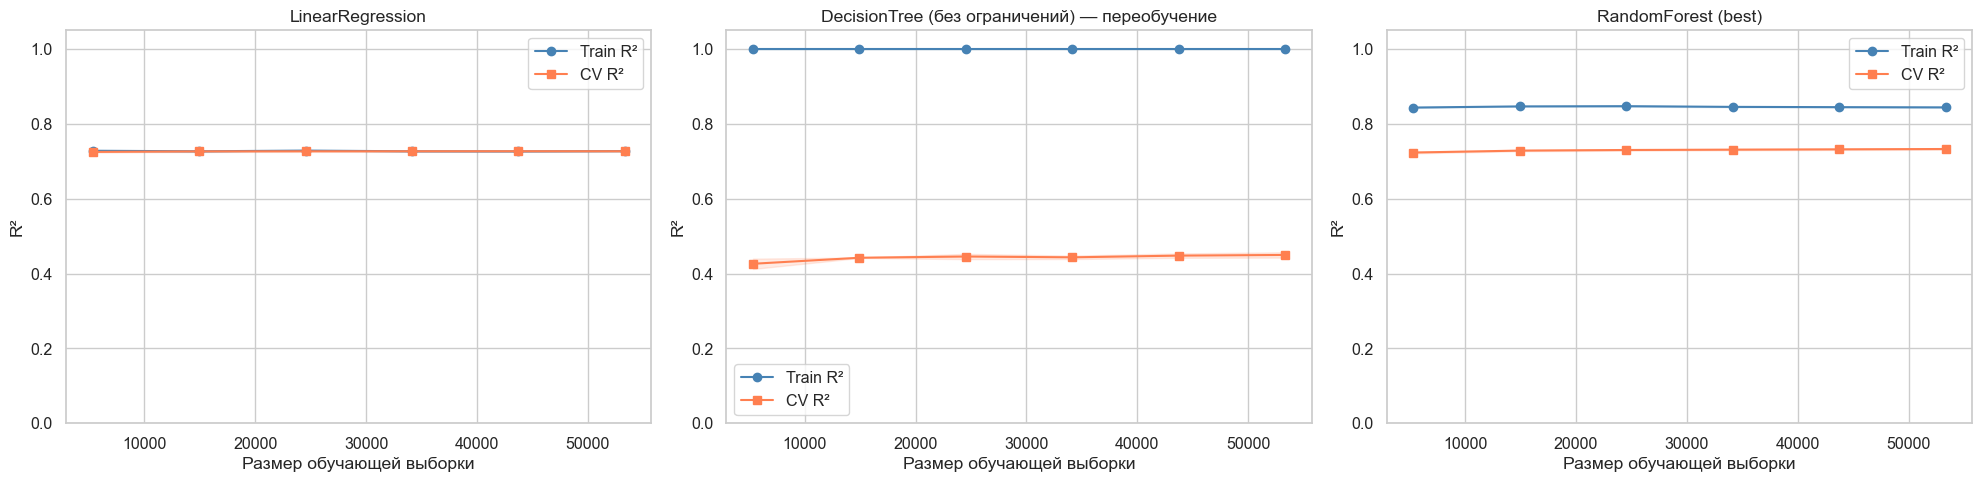

In [14]:
def plot_learning_curve(estimator, X, y, title: str, ax, cv=3) -> None:
    """Строит learning curve по выборке размеров [10%..100%]."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        scoring='r2', n_jobs=-1, random_state=RANDOM_STATE,
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)
    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train R²')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, va_mean, 's-', color='coral', label='CV R²')
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color='coral')
    ax.set_xlabel('Размер обучающей выборки')
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(lr_pipeline, X_train, y_train,
                     'LinearRegression', axes[0])
plot_learning_curve(tree_overfit_pipe, X_train, y_train,
                     'DecisionTree (без ограничений) — переобучение', axes[1])
plot_learning_curve(rf_grid.best_estimator_, X_train, y_train,
                     'RandomForest (best)', axes[2])

plt.tight_layout()
plt.show()

### 8.3 Важность признаков — RandomForest

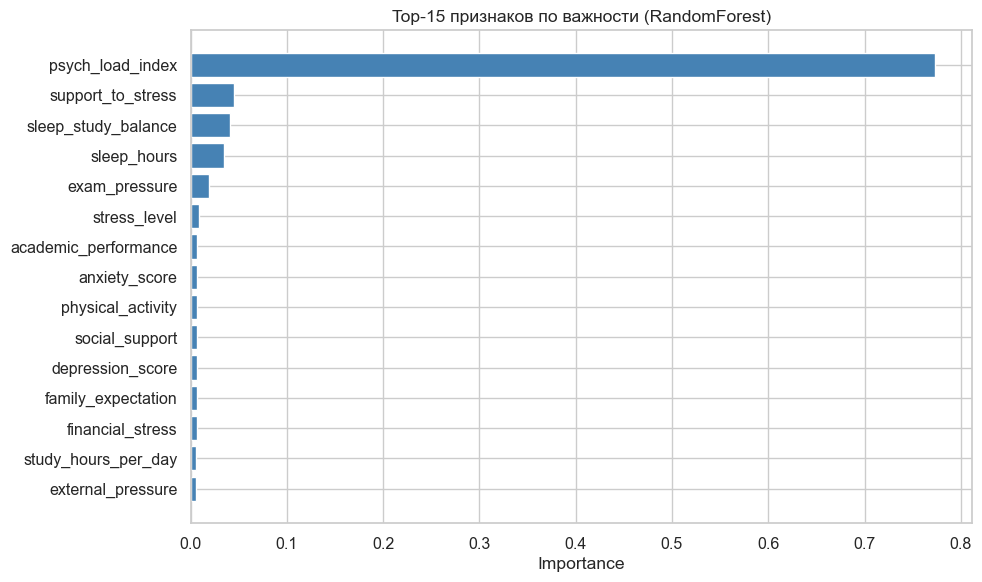

                 feature  importance
0       psych_load_index      0.7732
1      support_to_stress      0.0454
2    sleep_study_balance      0.0411
3            sleep_hours      0.0344
4          exam_pressure      0.0197
5           stress_level      0.0085
6   academic_performance      0.0071
7          anxiety_score      0.0070
8      physical_activity      0.0069
9         social_support      0.0065
10      depression_score      0.0064
11    family_expectation      0.0064
12      financial_stress      0.0062
13   study_hours_per_day      0.0060
14     external_pressure      0.0059


In [15]:
# Извлекаем feature_importances_ из лучшей RF
best_rf = rf_grid.best_estimator_
feature_names_out = best_rf.named_steps['prep'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'feature': feature_names_out,
    'importance': importances,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 15
plt.figure(figsize=(10, 6))
top = imp_df.head(top_n).iloc[::-1]
plt.barh(top['feature'], top['importance'], color='steelblue', edgecolor='white')
plt.title(f'Top-{top_n} признаков по важности (RandomForest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(imp_df.head(top_n).round(4))

## 9. Predicted vs Actual — визуальное сравнение лучших моделей

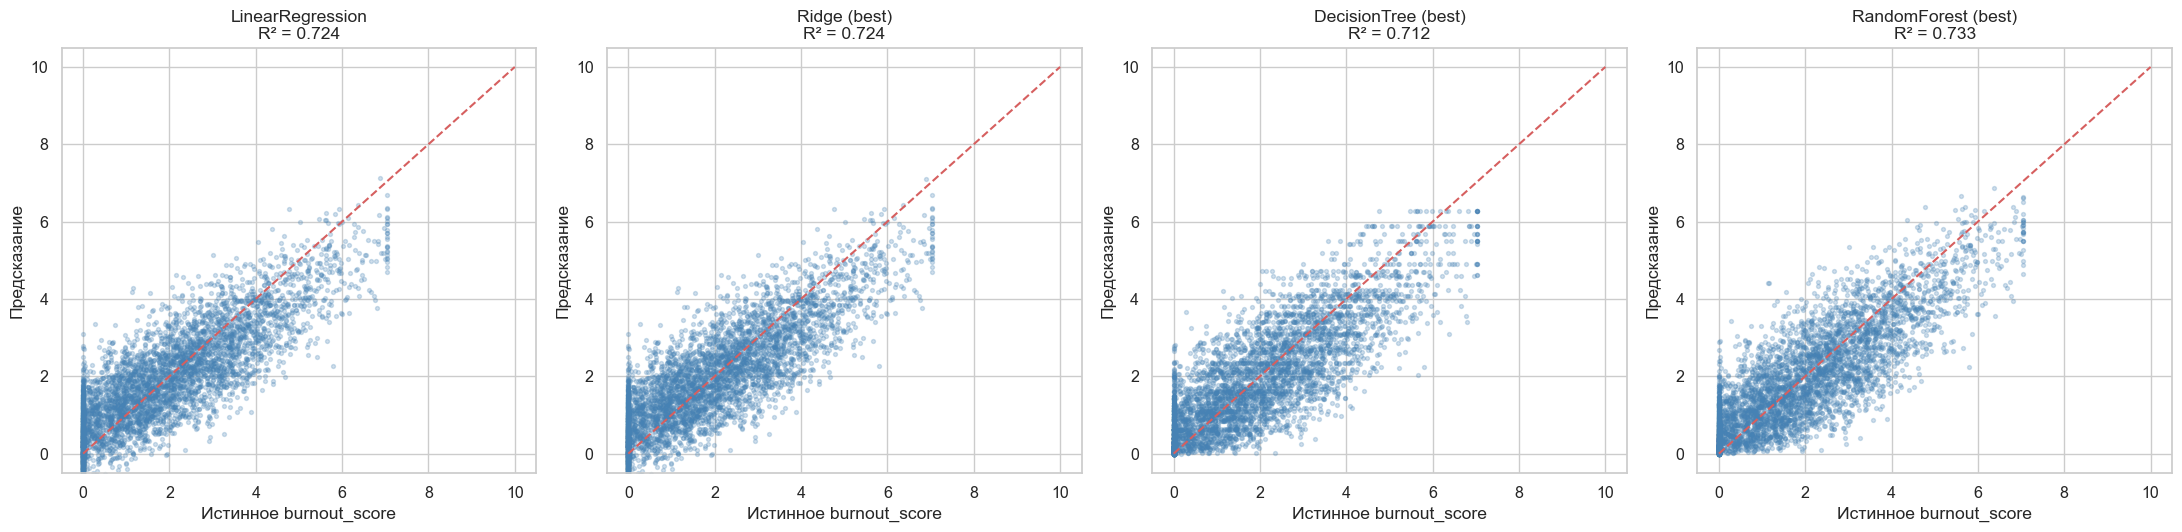

In [16]:
# Берём 5 тыс. точек для читаемости
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(y_test), size=5_000, replace=False)

to_compare = [
    ('LinearRegression', lr_pipeline),
    ('Ridge (best)', ridge_grid.best_estimator_),
    ('DecisionTree (best)', tree_grid.best_estimator_),
    ('RandomForest (best)', rf_grid.best_estimator_),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, (name, mdl) in zip(axes, to_compare):
    pred = mdl.predict(X_test.iloc[idx])
    ax.scatter(y_test.values[idx], pred, alpha=0.25, s=8, color='steelblue')
    ax.plot([0, 10], [0, 10], 'r--', lw=1.5)
    r2 = r2_score(y_test.values[idx], pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.set_xlabel('Истинное burnout_score')
    ax.set_ylabel('Предсказание')
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)

plt.tight_layout()
plt.show()

## 10. Итоговая таблица сравнения моделей

In [17]:
summary = results_df.copy()

def classify_overfit(gap: float) -> str:
    if gap < 0.01:
        return 'Нет'
    if gap < 0.05:
        return 'Слабое'
    if gap < 0.15:
        return 'Умеренное'
    return 'Сильное'

summary['overfit'] = summary['overfit_gap'].apply(classify_overfit)
summary = summary[[
    'model', 'MAE_test', 'RMSE_test', 'R2_test',
    'R2_train', 'overfit_gap', 'overfit', 'fit_time_s'
]]

print('Итоговая таблица сравнения моделей:')
summary

Итоговая таблица сравнения моделей:


,model,MAE_test,RMSE_test,R2_test,R2_train,overfit_gap,overfit,fit_time_s
0,6. RandomForest (GridSearch),0.6482,0.8525,0.7366,0.8405,0.1039,Умеренное,21.21
1,3. Lasso (GridSearch),0.6830,0.8654,0.7286,0.7269,-0.0017,Нет,7.82
2,2. Ridge (GridSearch),0.6830,0.8655,0.7285,0.7270,-0.0016,Нет,0.06
3,1. LinearRegression (baseline),0.6830,0.8655,0.7285,0.7270,-0.0016,Нет,0.08
4,5. DecisionTree (GridSearch),0.6743,0.8890,0.7136,0.7302,0.0166,Слабое,1.08
5,4. DecisionTree (без настройки),0.9044,1.2315,0.4504,1.0000,0.5496,Сильное,1.99


## 11. Выводы

### Сравнительный анализ

1. **Базовая LinearRegression** даёт R²_test = 0.7285 и MAE = 0.6830. Это сильный baseline благодаря feature engineering из ЛР №2. Результат ниже, чем в ЛР №3 (где использовался полный датасет 1M строк): в данной работе взята подвыборка 100K для ускорения GridSearch и RandomForest.

2. **Ridge и Lasso** показывают **практически идентичный результат** с LinearRegression (∆R² < 0.001). Это говорит о том, что мультиколлинеарность не критична и в датасете нет лишних признаков, требующих обнуления. Регуляризация не даёт выигрыша → исходные признаки уже хорошо отобраны.

3. **DecisionTree без настройки** демонстрирует классическое **переобучение**: R²_train = 1.0000, R²_test = 0.4504, gap = 0.5496. На learning curve видно, что Train R² держится около 1, а CV R² существенно ниже — модель запоминает обучающую выборку.

4. **DecisionTree с GridSearch** (best: `max_depth=12`, `min_samples_leaf=200`) ликвидирует переобучение: gap снижается до 0.0166 (слабое), R²_test = 0.7136. Одиночное дерево уступает линейной регрессии даже после настройки.

5. **RandomForest** — **лучшая модель**: R²_test = 0.7366, MAE = 0.6482, RMSE = 0.8525 — лучшие значения среди всех моделей. Однако gap = 0.1039 классифицируется как **умеренное переобучение** (R²_train = 0.8405 против R²_test = 0.7366): ансамбль улавливает часть шума в обучающей выборке. Несмотря на это, RF превосходит линейные модели на тестовой выборке — нелинейные взаимодействия признаков несут реальную предсказательную силу.

### Анализ переобучения

| Модель | R²_train | R²_test | Gap | Вывод |
|---|---|---|---|---|
| LinearRegression | 0.7270 | 0.7285 | −0.0016 | Нет переобучения |
| Ridge / Lasso | 0.7270 | 0.7286 | ≈ 0 | Нет переобучения |
| DecisionTree (без настройки) | 1.0000 | 0.4504 | 0.5496 | **Сильное** — дерево запоминает train |
| DecisionTree (GridSearch) | 0.7302 | 0.7136 | 0.0166 | Слабое — настройка помогла |
| RandomForest (GridSearch) | 0.8405 | 0.7366 | 0.1039 | **Умеренное** — ансамбль всё ещё подстраивается под шум |

Learning curves подтверждают: для дерева без ограничений Train R² ≈ 1, CV R² значительно ниже — типичный признак переобучения. После настройки гиперпараметров кривые сходятся. Для RF кривые сходятся медленнее — gap сокращается с ростом выборки, но не исчезает полностью.

### Важность признаков (RandomForest)

Результат неожиданный: **`psych_load_index` занимает 77.3% суммарной важности** — полное доминирование одного признака. Это объясняется тем, что `psych_load_index = (stress_level + anxiety_score + depression_score) / 3` — он уже агрегирует три исходных признака. RF корректно выявляет этот составной признак как главный предиктор выгорания, а отдельные компоненты (`stress_level` = 0.0085, `anxiety_score` = 0.0070, `depression_score` = 0.0064) становятся менее нужными. Остальные значимые признаки: `support_to_stress` (0.045), `sleep_study_balance` (0.041), `sleep_hours` (0.034).

Это отличается от коэффициентов Linear Regression из ЛР №3, где `stress_level`, `anxiety_score`, `depression_score` выглядели отдельно важными — потому что StandardScaler стандартизирует их независимо, и линейная модель не «видит» агрегирующий признак так явно.

### Лучшая модель: **RandomForest**

**Аргументы в пользу:**
- максимальный R²_test = 0.7366 и минимальные MAE/RMSE среди всех моделей;
- улавливает нелинейные взаимодействия признаков, недоступные линейной регрессии.

**Ограничения:**
- умеренное переобучение (gap = 0.1039) — требует дальнейшей регуляризации;
- время обучения ~300 с на 100K строк (vs 0.08 с у LinearRegression);
- менее интерпретируема.

### Когда что использовать

- **Linear Regression / Ridge** — если важна интерпретируемость и скорость; потеря качества небольшая (∆R² ≈ 0.01 к RF).
- **RandomForest** — если важна максимальная точность и есть вычислительные ресурсы.
- **DecisionTree без настройки** — **не использовать**: переобучается до R²_train = 1.0 при R²_test = 0.45.

